# GVF HyperAgents Experiment Results


## paper review


In [2]:
HYPERAGENTS_LOG_DIR = "/scratch/mikezhu/HyperAgents/experiments/paper-review-original-full-qwen38/outputs-before-de006a7-20260913-210130/generate_paper_review_original_full_qwen38_long_run1_private"
COMPRESSED_LOG_DIR = "/scratch/mikezhu/HyperAgents/experiments/paper-review-original-compressed10-qwen38/outputs-before-de006a7-20260913-210130/generate_paper_review_original_compressed10_qwen38_long_run1_private"
GVF_LOG_DIR = "/scratch/mikezhu/HyperAgents/experiments/paper-review-gvf-compressed10-lambda1-qwen38/outputs-before-2589065-20260913-210130/generate_paper_review_gvf_compressed10_lambda1_qwen38_long_run1_private"
GVF_REASON_LOG_DIR = "/scratch/mikezhu/HyperAgents/experiments/paper-review-gvf-reason-compressed10-qwen38/outputs-before-2589065-20260913-210130/generate_paper_review_gvf_reason_compressed10_qwen38_long_run1_private"

In [3]:
FIGURE_PATH = "/scratch/mikezhu/HyperAgents/HyperAgentsInfra/outputs/paper_review_results.png"


In [4]:
CHECKPOINTS_M = [6, 12, 24, 48]

In [5]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

methods = {
    "HyperAgents": Path(HYPERAGENTS_LOG_DIR),
    "Compressed HyperAgents": Path(COMPRESSED_LOG_DIR),
    "GVF HyperAgents": Path(GVF_LOG_DIR),
    "GVF HyperAgents (Reasoned Selector)": Path(GVF_REASON_LOG_DIR),
}
checkpoint_values = [float(value) for value in CHECKPOINTS_M]

rows = []
for method, result_dir in methods.items():
    for checkpoint_m in checkpoint_values:
        budget = int(checkpoint_m * 1_000_000)
        checkpoint_path = result_dir / "checkpoints" / f"checkpoint_T{budget}.json"
        checkpoint = json.loads(checkpoint_path.read_text(encoding="utf-8"))
        run_label = checkpoint.get("test_run_id", f"budget_{budget}")
        row = {
            "method": method,
            "checkpoint_m": checkpoint_m,
            "selected_generation": checkpoint["selected_version_id"],
        }
        if "test_config" in checkpoint:
            summary_path = result_dir / "private_test_results" / f"{run_label}_summary.json"
            summary = json.loads(summary_path.read_text(encoding="utf-8"))
            stats = summary["domains"]["paper_review"]
            if stats["repeat_count"] != checkpoint["test_config"]["repeats"]:
                raise ValueError(f"Incomplete repeated tests: {summary_path}")
            row.update(
                correct=stats["mean"] * stats["num_samples"],
                samples=stats["num_samples"],
                accuracy_pct=100 * stats["mean"],
                accuracy_std_pct=100 * stats["std"] if stats["std"] is not None else float("nan"),
                test_repeats=stats["repeat_count"],
                test_scores=stats["scores"],
                reused_from=summary["reused_from"],
            )
        else:
            # Historical single-test runs have no repeat standard deviation.
            report_path = (result_dir / "private_test_results"
                           / f"{run_label}_paper_review_0" / "paper_review" / "report.json")
            report = json.loads(report_path.read_text(encoding="utf-8"))
            row.update(
                correct=report["total_correct"], samples=report["total"],
                accuracy_pct=100 * report["overall_accuracy"],
                accuracy_std_pct=float("nan"), test_repeats=1,
                test_scores=[report["overall_accuracy"]], reused_from=None,
            )
        rows.append(row)

results = pd.DataFrame(rows)
results

,method,checkpoint_m,selected_generation,correct,samples,accuracy_pct
0,HyperAgents,6.0,initial,0,50,0.0
1,HyperAgents,12.0,1,4,50,8.0
2,HyperAgents,24.0,4,39,50,78.0
3,HyperAgents,48.0,5,43,50,86.0
4,Compressed HyperAgents,6.0,initial,0,50,0.0
5,Compressed HyperAgents,12.0,7,0,50,0.0
6,Compressed HyperAgents,24.0,12,43,50,86.0
7,Compressed HyperAgents,48.0,12,42,50,84.0
8,GVF HyperAgents,6.0,2,43,50,86.0
9,GVF HyperAgents,12.0,3,36,50,72.0


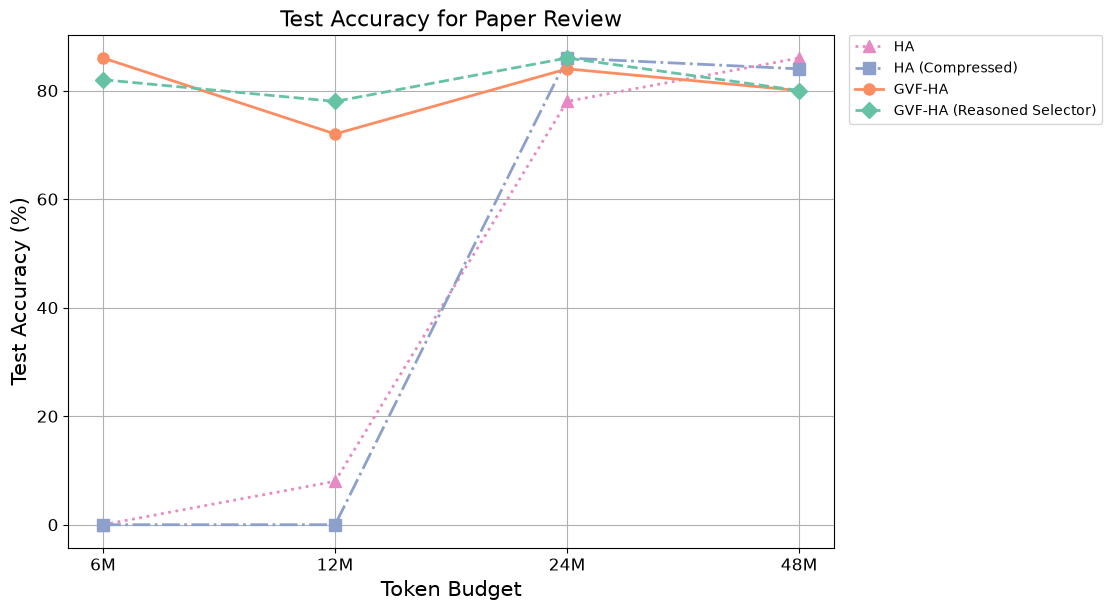

In [6]:
positions = list(range(len(checkpoint_values)))
colors = [plt.get_cmap("Set2").colors[i] for i in (3, 2, 1, 0)]
markers = ("^", "s", "o", "D")
line_styles = (":", "-.", "-", "--")

fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
for index, method in enumerate(methods):
    accuracy = (
        results.loc[results["method"] == method]
        .set_index("checkpoint_m")["accuracy_pct"]
        .reindex(checkpoint_values)
    )
    ax.plot(
        positions,
        accuracy,
        label=method,
        color=colors[index],
        marker=markers[index],
        markerfacecolor=colors[index],
        markeredgecolor=colors[index],
        markersize=8,
        linestyle=line_styles[index],
        linewidth=2,
    )

ax.set_xticks(positions, [f"{value:g}M" for value in checkpoint_values])
ax.set_xlabel("Token Budget", fontsize=15)
ax.set_ylabel("Test Accuracy (%)", fontsize=15)
ax.set_title("Test Accuracy for Paper Review", fontsize=16)
ax.set_yticks(range(0, 90, 20))
ax.tick_params(axis="both", labelsize=12)
ax.margins(x=0.05)
ax.set_axisbelow(True)
ax.grid(True)
ax.legend(
    labels=("HA", "HA (Compressed)", "GVF-HA", "GVF-HA (Reasoned Selector)"),
    loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0,
    frameon=True, fontsize=10,
)
figure_path = Path(FIGURE_PATH)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

In [7]:
QUESTION_TYPE_CSV_PATH = "/scratch/mikezhu/HyperAgents/HyperAgentsInfra/outputs/paper_review_gvf_question_type_analyse.csv"
QUESTION_TYPE_FIGURE_PATH = "/scratch/mikezhu/HyperAgents/HyperAgentsInfra/outputs/paper_review_gvf_question_type_heatmap.png"

In [62]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

question_types = pd.read_csv(QUESTION_TYPE_CSV_PATH).sort_values("generation")
question_type_labels = {
    "interface_label_share": "Implementation\nreliability",
    "policy_mechanism_label_share": "Current\npolicy design",
    "history_comparison_label_share": "Cross-version\nanalysis",
    "exploration_label_share": "Exploration",
}
question_type_heatmap = (
    question_types.set_index("generation")[list(question_type_labels)]
    .rename(columns=question_type_labels).T * 100
)

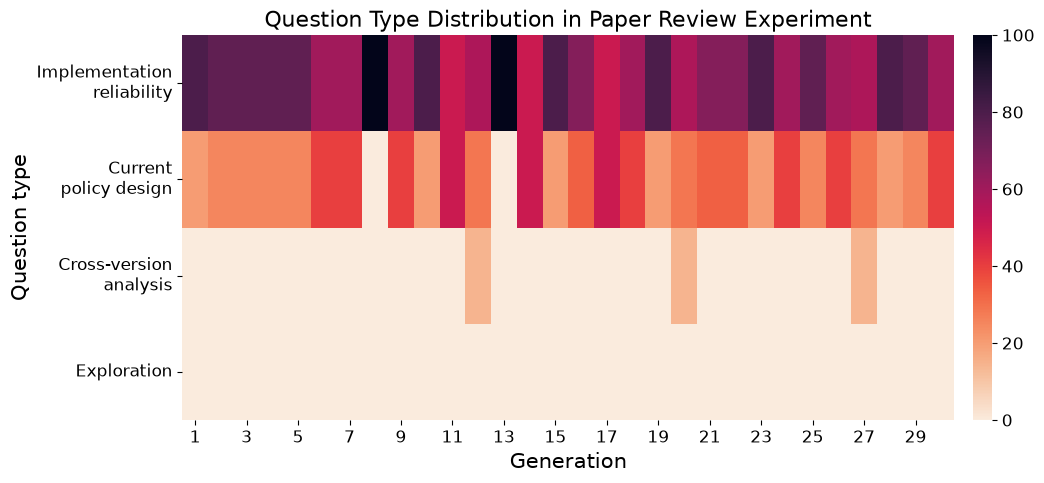

In [64]:
heatmap_fig, heatmap_ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    question_type_heatmap, cmap="rocket_r", ax=heatmap_ax,
    cbar_kws={"pad": 0.02},
)
heatmap_ax.set_xticks(
    [position + 0.5 for position in range(0, len(question_type_heatmap.columns), 2)],
    labels=question_type_heatmap.columns[::2],
)
heatmap_ax.set_xlabel("Generation", fontsize=15)
heatmap_ax.set_ylabel("Question type", fontsize=15)
heatmap_ax.set_title("Question Type Distribution in Paper Review Experiment", fontsize=16)
heatmap_ax.tick_params(axis="both", labelsize=12)
heatmap_ax.set_yticklabels(heatmap_ax.get_yticklabels(), rotation=0)
heatmap_colorbar = heatmap_ax.collections[0].colorbar
heatmap_colorbar.ax.tick_params(labelsize=12)
question_type_figure_path = Path(QUESTION_TYPE_FIGURE_PATH)
question_type_figure_path.parent.mkdir(parents=True, exist_ok=True)
heatmap_fig.savefig(question_type_figure_path, dpi=300, bbox_inches="tight")
plt.show()